In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

print("After preprocessing:")
print("Train:", x_train.shape)
print("Test :", x_test.shape)

After preprocessing:
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


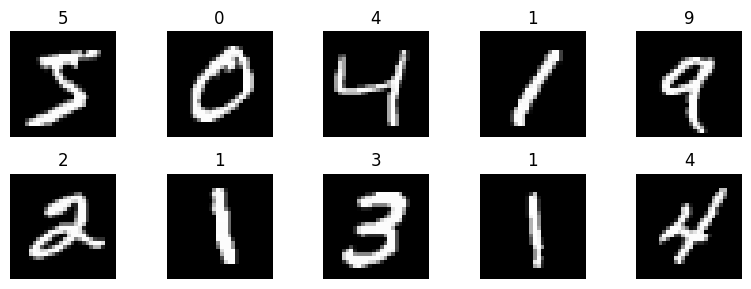

In [ ]:
plt.figure(figsize=(8,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(int(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

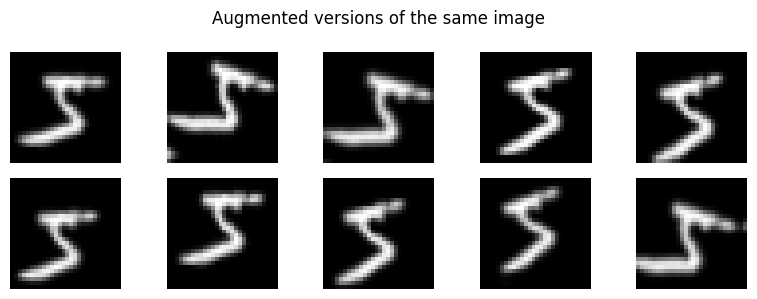

In [ ]:
sample = x_train[0:1]  # one image

plt.figure(figsize=(8,3))
for i in range(10):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2,5,i+1)
    plt.imshow(augmented[0].numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Augmented versions of the same image")
plt.tight_layout()
plt.show()

In [ ]:
def build_cnn_baseline():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="CNN_Baseline_NoDropout")
    return model

model_a = build_cnn_baseline()
model_a.summary()

Model: "CNN_Baseline_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_a.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_a = model_a.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 122ms/step - accuracy: 0.7231 - loss: 0.8685 - val_accuracy: 0.9763 - val_loss: 0.0695
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - accuracy: 0.9468 - loss: 0.1747 - val_accuracy: 0.9821 - val_loss: 0.0493
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.9640 - loss: 0.1182 - val_accuracy: 0.9848 - val_loss: 0.0438
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.9724 - loss: 0.0902 - val_accuracy: 0.9865 - val_loss: 0.0419
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 115ms/step - accuracy: 0.9769 - loss: 0.0754 - val_accuracy: 0.9848 - val_loss: 0.0486
